# Cyclone Ditwa Event Window Analysis — Sri Lanka Tea Auction Prices

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

df = pd.read_csv('../data/processed/master_tea_prices.csv')
print(f"Loaded {df.shape[0]:,} records across {df['sale_id'].nunique()} auction sales")

Loaded 7,100 records across 35 auction sales


In [13]:
# ── Event window definition ───────────────────────────────────────────────────
# Cyclone Ditwa made landfall near Sri Lanka's north-eastern coast in late
# November 2025 and disrupted growing regions through January 2026.
# We define three windows based on the Colombo Tea Auction calendar:
#   Pre-event  : April – October 2025  (sales 16 – 42)
#   Event      : November 2025 – January 2026  (sales 43 – 50, 01–04)
#   Post-event : February – March 2026  (sales 05 – 10)

DITWA_START_SALE = 'SALE_45_2025'
DITWA_END_SALE   = 'SALE_01_2026'

# ── Aggregate to auction-level prices ────────────────────────────────────────
sale_agg = (
    df.groupby(['sale_id', 'sale_year', 'sale_month', 'sale_number'])
    .agg(
        price_hi_mean   = ('price_hi_lkr', 'mean'),
        price_hi_max    = ('price_hi_lkr', 'max'),
        price_mid_mean  = ('price_mid_lkr', 'mean'),
        price_mid_median= ('price_mid_lkr', 'median'),
        price_lo_mean   = ('price_lo_lkr', 'mean'),
    )
    .reset_index()
    .sort_values(['sale_year', 'sale_number'])
    .reset_index(drop=True)
)

# Chronological index (1 = first auction in dataset)
sale_agg['auction_idx'] = range(1, len(sale_agg) + 1)

# Window labels
def label_window(sale_id):
    sale_ids = sale_agg['sale_id'].tolist()
    start_i = sale_ids.index(DITWA_START_SALE)
    end_i   = sale_ids.index(DITWA_END_SALE)
    idx = sale_ids.index(sale_id)
    if idx < start_i:
        return 'pre'
    elif idx <= end_i:
        return 'event'
    else:
        return 'post'

sale_agg['window'] = sale_agg['sale_id'].apply(label_window)

# ── Baseline: mean of pre-event prices ───────────────────────────────────────
pre = sale_agg[sale_agg['window'] == 'pre']
baseline_hi   = pre['price_hi_mean'].mean()
baseline_mid  = pre['price_mid_mean'].mean()

sale_agg['hi_pct_change']  = (sale_agg['price_hi_mean']  / baseline_hi  - 1) * 100
sale_agg['mid_pct_change'] = (sale_agg['price_mid_mean'] / baseline_mid - 1) * 100

# ── Event window indices for shading ─────────────────────────────────────────
event_mask  = sale_agg['window'] == 'event'
event_start = sale_agg.loc[event_mask, 'auction_idx'].min() - 0.5
event_end   = sale_agg.loc[event_mask, 'auction_idx'].max() + 0.5

print("Auction sales per window:")
print(sale_agg.groupby('window')['sale_id'].count().reindex(['pre','event','post']))
print(f"\nPre-event baseline  — High avg: LKR {baseline_hi:.0f}  |  Mid avg: LKR {baseline_mid:.0f}")
event_hi  = sale_agg.loc[event_mask, 'price_hi_mean'].mean()
event_mid = sale_agg.loc[event_mask, 'price_mid_mean'].mean()
print(f"Event window mean   — High avg: LKR {event_hi:.0f}  |  Mid avg: LKR {event_mid:.0f}")
print(f"Change              — High: {(event_hi/baseline_hi-1)*100:+.1f}%  |  Mid: {(event_mid/baseline_mid-1)*100:+.1f}%")

Auction sales per window:
window
pre      18
event     7
post      9
Name: sale_id, dtype: int64

Pre-event baseline  — High avg: LKR 1354  |  Mid avg: LKR 1236
Event window mean   — High avg: LKR 1434  |  Mid avg: LKR 1304
Change              — High: +5.9%  |  Mid: +5.5%


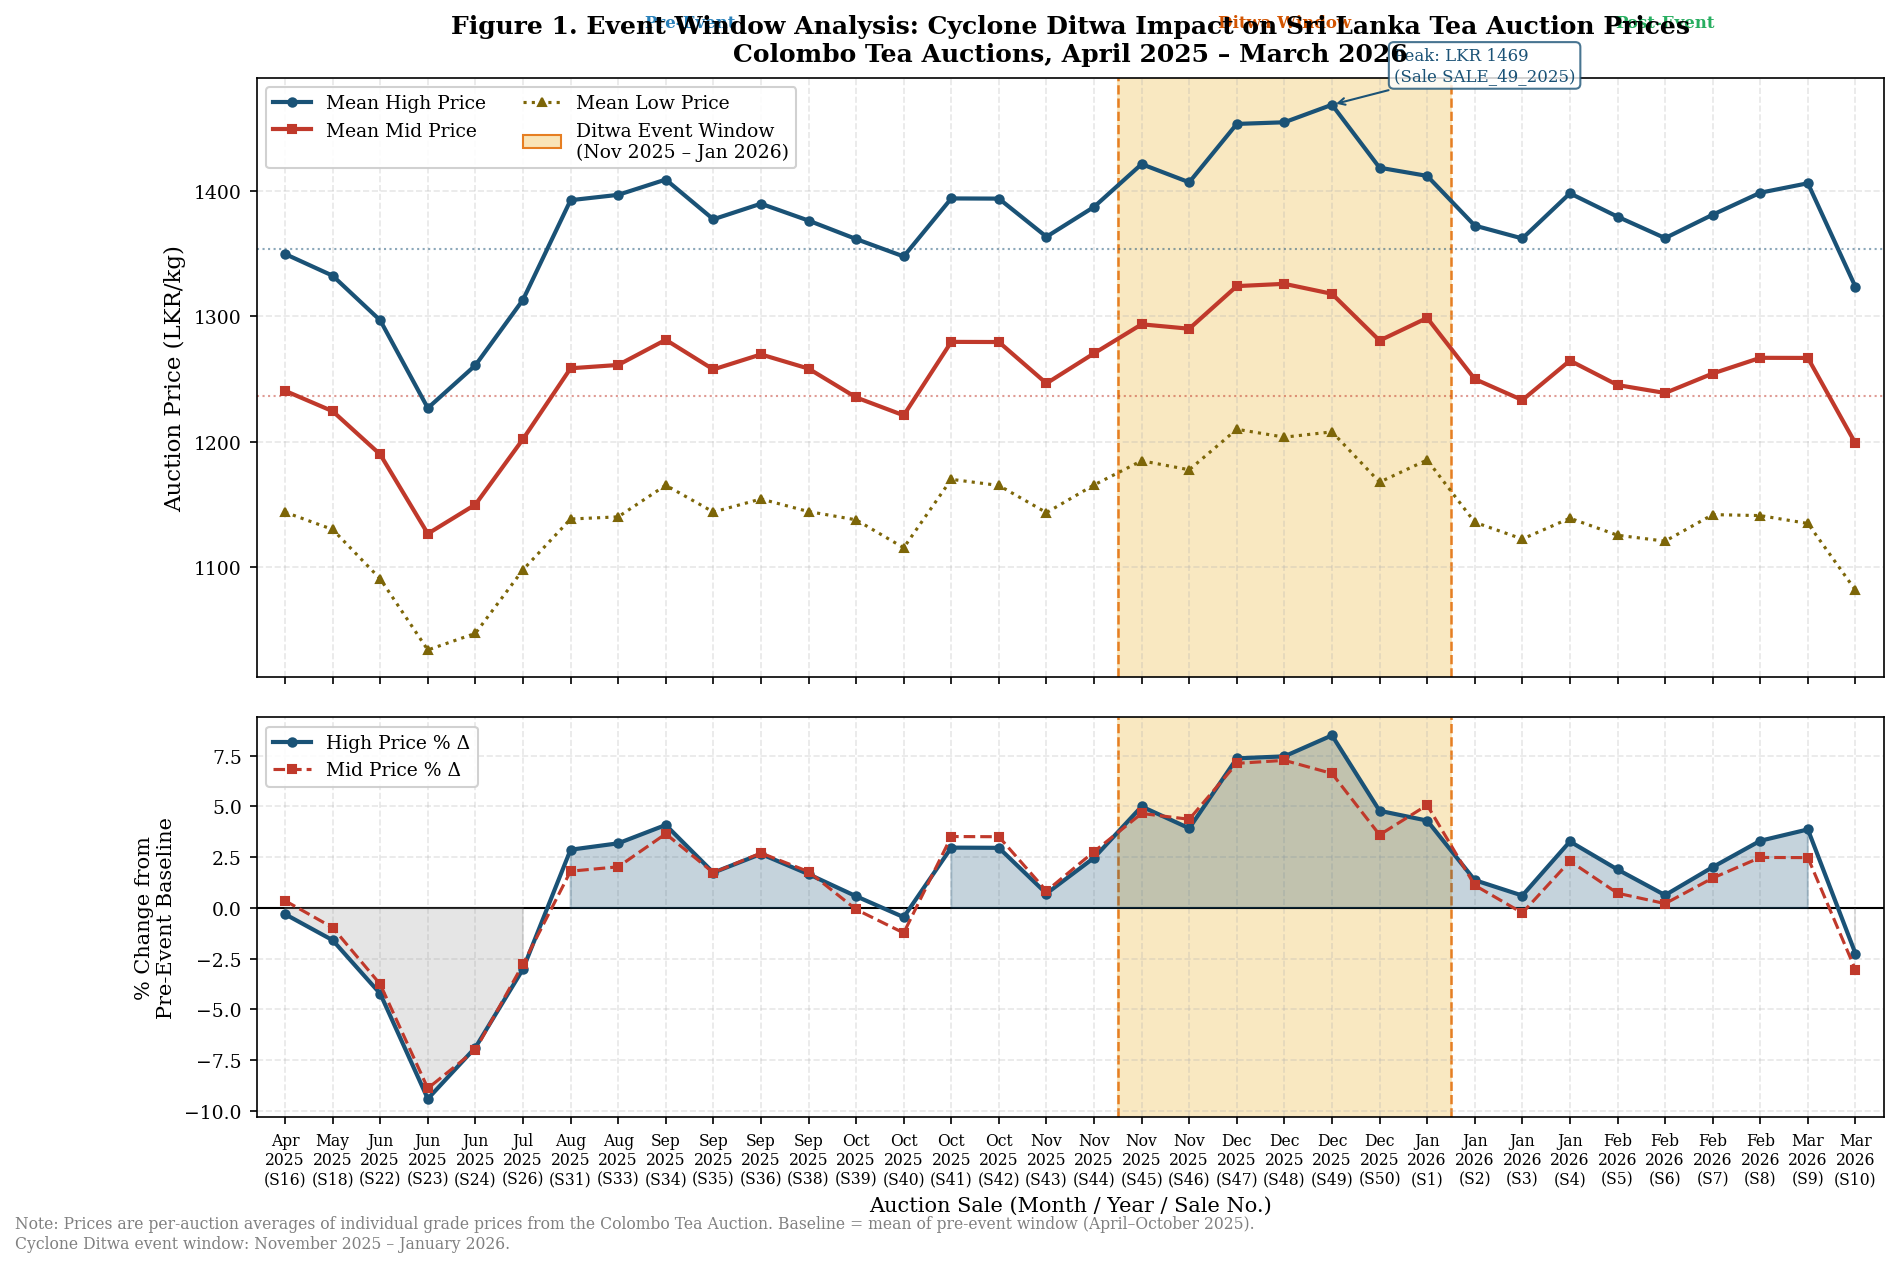

Figure saved to data/ditwa_event_window_analysis.png


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.08})

x   = sale_agg['auction_idx']
col_hi  = '#1a5276'
col_mid = '#c0392b'
col_lo  = '#7d6608'
shade   = '#f9e4b7'
shade_edge = '#e67e22'

# ─── Panel A: Price levels ────────────────────────────────────────────────────
ax1 = axes[0]
ax1.axvspan(event_start, event_end, color=shade, alpha=0.85, zorder=0, label='_nolegend_')
ax1.axvline(event_start, color=shade_edge, lw=1.2, ls='--', zorder=1)
ax1.axvline(event_end,   color=shade_edge, lw=1.2, ls='--', zorder=1)

ax1.plot(x, sale_agg['price_hi_mean'],   color=col_hi,  lw=2,   marker='o', ms=4, zorder=3, label='Mean High Price')
ax1.plot(x, sale_agg['price_mid_mean'],  color=col_mid, lw=2,   marker='s', ms=4, zorder=3, label='Mean Mid Price')
ax1.plot(x, sale_agg['price_lo_mean'],   color=col_lo,  lw=1.5, marker='^', ms=3.5, ls=':', zorder=3, label='Mean Low Price')

# Baseline line
ax1.axhline(baseline_hi,  color=col_hi,  lw=1,  ls=':', alpha=0.5)
ax1.axhline(baseline_mid, color=col_mid, lw=1,  ls=':', alpha=0.5)

# Peak annotation
peak_idx = sale_agg.loc[event_mask, 'price_hi_mean'].idxmax()
peak_x   = sale_agg.loc[peak_idx, 'auction_idx']
peak_y   = sale_agg.loc[peak_idx, 'price_hi_mean']
ax1.annotate(f'Peak: LKR {peak_y:.0f}\n(Sale {sale_agg.loc[peak_idx,"sale_id"]})',
             xy=(peak_x, peak_y), xytext=(peak_x + 1.3, peak_y + 20),
             fontsize=8, color=col_hi,
             arrowprops=dict(arrowstyle='->', color=col_hi, lw=1),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col_hi, alpha=0.8))

ax1.set_ylabel('Auction Price (LKR/kg)', fontsize=11)
ax1.set_title('Figure 1. Event Window Analysis: Cyclone Ditwa Impact on Sri Lanka Tea Auction Prices\n'
              'Colombo Tea Auctions, April 2025 – March 2026',
              fontsize=12, fontweight='bold', pad=8)

ditwa_patch = mpatches.Patch(color=shade, ec=shade_edge, label='Ditwa Event Window\n(Nov 2025 – Jan 2026)')
legend_lines = [
    Line2D([0],[0], color=col_hi,  lw=2, marker='o', ms=4, label='Mean High Price'),
    Line2D([0],[0], color=col_mid, lw=2, marker='s', ms=4, label='Mean Mid Price'),
    Line2D([0],[0], color=col_lo,  lw=1.5, marker='^', ms=3.5, ls=':', label='Mean Low Price'),
    ditwa_patch,
]
ax1.legend(handles=legend_lines, loc='upper left', framealpha=0.9, ncol=2)

# Window bracket labels
def bracket_label(ax, x0, x1, y, text, color):
    ax.annotate('', xy=(x1, y), xytext=(x0, y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.2))
    ax.text((x0+x1)/2, y, text, ha='center', va='bottom', fontsize=8,
            color=color, fontweight='bold')

ymax = sale_agg['price_hi_mean'].max() * 1.04
pre_x0, pre_x1   = sale_agg.loc[sale_agg['window']=='pre', 'auction_idx'].agg(['min','max'])
post_x0, post_x1 = sale_agg.loc[sale_agg['window']=='post','auction_idx'].agg(['min','max'])
bracket_label(ax1, pre_x0 - 0.4, pre_x1 + 0.4,  ymax, 'Pre-Event', '#2980b9')
bracket_label(ax1, event_start,  event_end,        ymax, 'Ditwa Window', '#d35400')
bracket_label(ax1, post_x0 - 0.4, post_x1 + 0.4, ymax, 'Post-Event', '#27ae60')

# ─── Panel B: % deviation from pre-event baseline ────────────────────────────
ax2 = axes[1]
ax2.axvspan(event_start, event_end, color=shade, alpha=0.85, zorder=0)
ax2.axvline(event_start, color=shade_edge, lw=1.2, ls='--', zorder=1)
ax2.axvline(event_end,   color=shade_edge, lw=1.2, ls='--', zorder=1)
ax2.axhline(0, color='black', lw=1, zorder=2)

ax2.fill_between(x, 0, sale_agg['hi_pct_change'],
                 where=sale_agg['hi_pct_change'] >= 0,
                 color=col_hi, alpha=0.25, zorder=3)
ax2.fill_between(x, 0, sale_agg['hi_pct_change'],
                 where=sale_agg['hi_pct_change'] < 0,
                 color='grey', alpha=0.2, zorder=3)
ax2.plot(x, sale_agg['hi_pct_change'],  color=col_hi,  lw=2,   marker='o', ms=4, zorder=4, label='High Price % Δ')
ax2.plot(x, sale_agg['mid_pct_change'], color=col_mid, lw=1.5, marker='s', ms=3.5, ls='--', zorder=4, label='Mid Price % Δ')

ax2.set_ylabel('% Change from\nPre-Event Baseline', fontsize=10)
ax2.legend(loc='upper left', framealpha=0.9)

# ─── Shared x-axis: auction sale labels ──────────────────────────────────────
tick_labels = sale_agg.apply(
    lambda r: f"{r['sale_month'][:3]}\n{int(r['sale_year'])}\n(S{int(r['sale_number'])})", axis=1
)
ax2.set_xticks(x)
ax2.set_xticklabels(tick_labels, fontsize=7.5)
ax2.set_xlabel('Auction Sale (Month / Year / Sale No.)', fontsize=10)
ax2.set_xlim(x.min() - 0.6, x.max() + 0.6)

fig.text(0.01, 0.01,
         'Note: Prices are per-auction averages of individual grade prices from the Colombo Tea Auction. '
         'Baseline = mean of pre-event window (April–October 2025).\n'
         'Cyclone Ditwa event window: November 2025 – January 2026.',
         fontsize=7.5, color='grey', va='bottom')

plt.savefig('../data/ditwa_event_window_analysis.png', bbox_inches='tight', dpi=200)
plt.show()
print("Figure saved to data/ditwa_event_window_analysis.png")

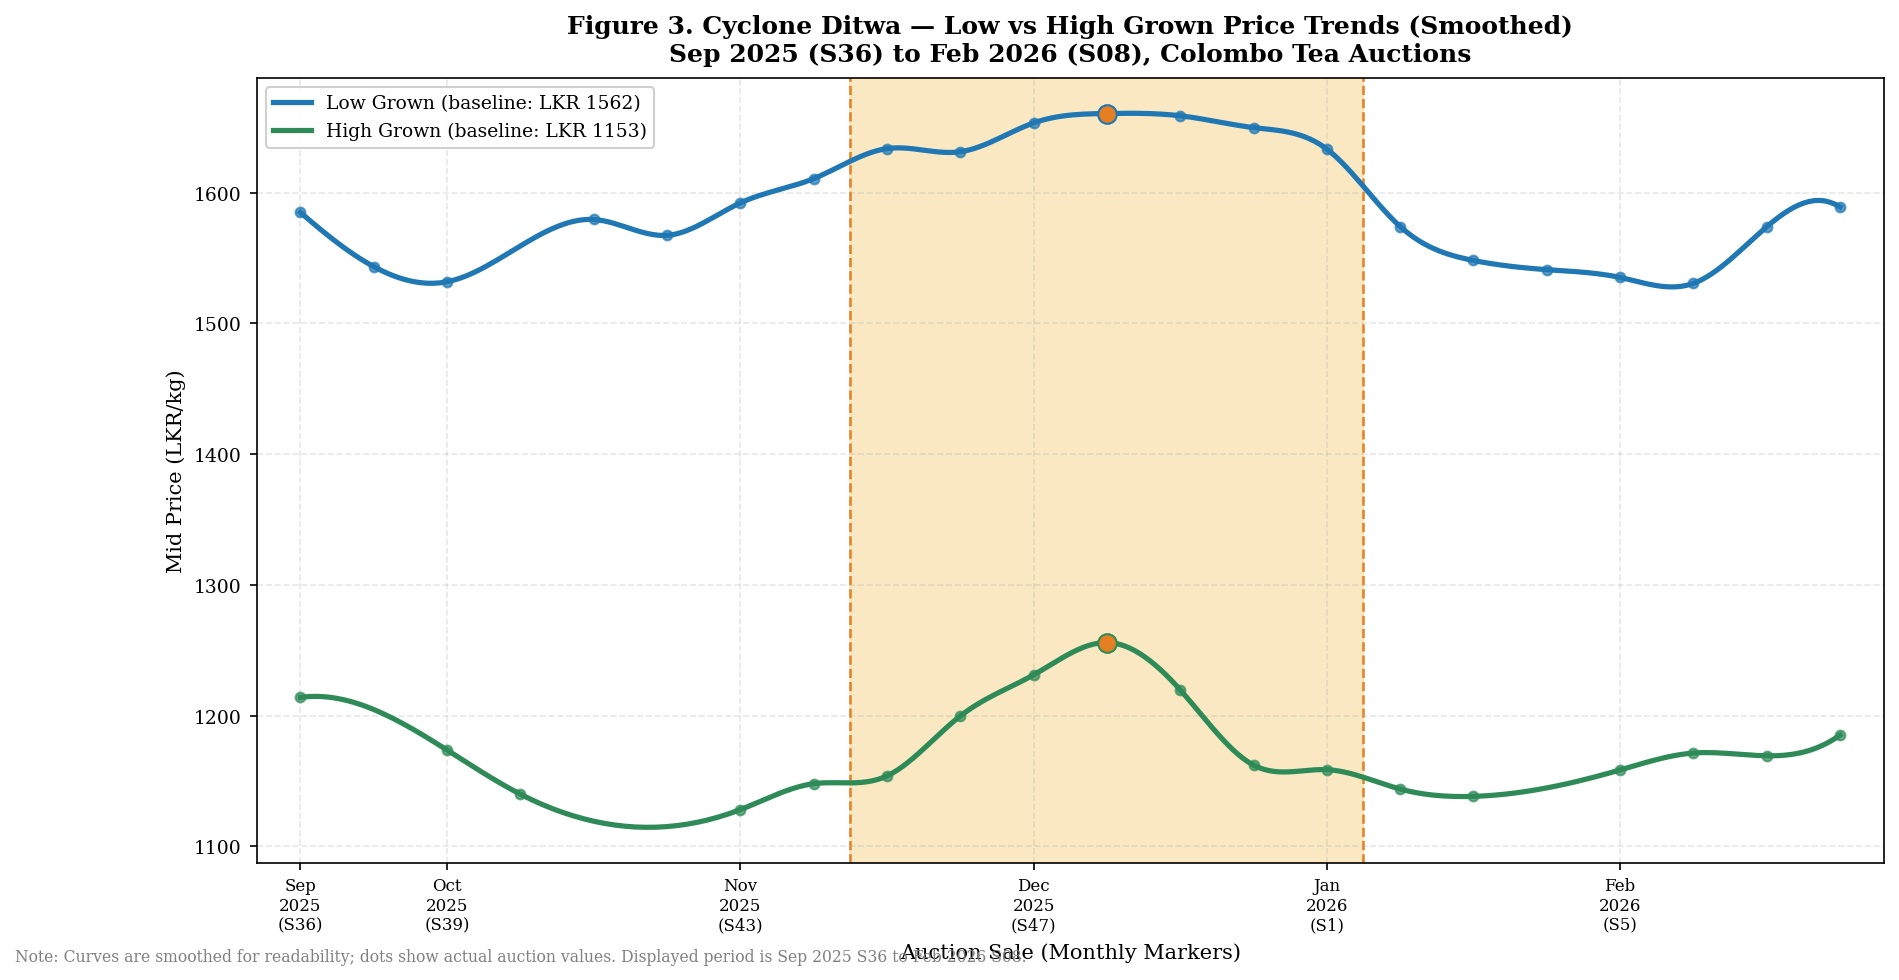

Figure saved to data/ditwa_segment_breakdown.png


In [ ]:
# ── Supplementary: Segment-based price movement in one graph (smoothed) ───────
from scipy.interpolate import make_interp_spline

segment_order = ['low_grown', 'high_grown']
segment_labels = {
    'low_grown': 'Low Grown',
    'high_grown': 'High Grown',
}
segment_colors = {
    'low_grown': '#1f77b4',
    'high_grown': '#2e8b57',
}

# Analysis window requested: Sep 2025 (Sale 36) to Feb 2026 (Sale 08)
WINDOW_START_SALE = 'SALE_36_2025'
WINDOW_END_SALE = 'SALE_08_2026'

# Keep this cell self-contained (no dependency on previous plotting cells).
shade = '#f9e4b7'
shade_edge = '#e67e22'
event_mask = sale_agg['window'] == 'event'
event_start_all = sale_agg.loc[event_mask, 'auction_idx'].min() - 0.5
event_end_all = sale_agg.loc[event_mask, 'auction_idx'].max() + 0.5

sale_ids = sale_agg['sale_id'].tolist()
start_idx = sale_ids.index(WINDOW_START_SALE)
end_idx = sale_ids.index(WINDOW_END_SALE)
window_sale_ids = sale_ids[start_idx:end_idx + 1]

sale_agg_window = sale_agg[sale_agg['sale_id'].isin(window_sale_ids)].copy()
x_min = sale_agg_window['auction_idx'].min() - 0.6
x_max = sale_agg_window['auction_idx'].max() + 0.6

seg_agg = (
    df[df['category_type'].isin(segment_order)]
    .groupby(['sale_id', 'sale_year', 'sale_number', 'sale_month', 'category_type'])['price_mid_lkr']
    .mean()
    .reset_index()
    .sort_values(['sale_year', 'sale_number'])
)
seg_agg = seg_agg.merge(sale_agg[['sale_id', 'auction_idx', 'window']], on='sale_id', how='left')
seg_agg = seg_agg[seg_agg['sale_id'].isin(window_sale_ids)].copy()

fig3, ax3 = plt.subplots(figsize=(14, 6.8))

# Draw event window shading clipped to current display window
event_start = max(event_start_all, x_min)
event_end = min(event_end_all, x_max)
if event_start < event_end:
    ax3.axvspan(event_start, event_end, color=shade, alpha=0.85, zorder=0)
    ax3.axvline(event_start, color=shade_edge, lw=1.2, ls='--', zorder=1)
    ax3.axvline(event_end, color=shade_edge, lw=1.2, ls='--', zorder=1)



for seg in segment_order:
    sub = seg_agg[seg_agg['category_type'] == seg].copy().sort_values('auction_idx')
    if sub.empty:
        continue

    # Keep baseline from full pre-event period for consistency
    baseline_full = (
        df[(df['category_type'] == seg) & (df['sale_id'].isin(sale_agg[sale_agg['window'] == 'pre']['sale_id']))]
        ['price_mid_lkr']
        .mean()
    )

    x_raw = sub['auction_idx'].to_numpy()
    y_raw = sub['price_mid_lkr'].to_numpy()
    x_raw = np.delete(x_raw, 3)  # Remove first point to avoid interpolation issues
    y_raw = np.delete(y_raw, 3)
    # Smoothed curve while preserving raw points for visible spikes
    if len(sub) >= 4:
        x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)
        y_smooth = make_interp_spline(x_raw, y_raw, k=3)(x_smooth)
    elif len(sub) >= 2:
        x_smooth = np.linspace(x_raw.min(), x_raw.max(), 200)
        y_smooth = np.interp(x_smooth, x_raw, y_raw)
    else:
        x_smooth = x_raw
        y_smooth = y_raw

    ax3.plot(
        x_smooth, y_smooth,
        color=segment_colors[seg],
        lw=2.5,
        label=f"{segment_labels[seg]} (baseline: LKR {baseline_full:.0f})",
        zorder=3,
    )

    # Original observations as points so spikes remain visible
    ax3.scatter(
        x_raw, y_raw,
        color=segment_colors[seg],
        s=22,
        alpha=0.7,
        zorder=4,
    )

    # Highlight event-window peak within this displayed time window
    ev_sub = sub[sub['window'] == 'event']
    if len(ev_sub):
        pk = ev_sub.loc[ev_sub['price_mid_lkr'].idxmax()]
        ax3.scatter(
            [pk['auction_idx']], [pk['price_mid_lkr']],
            color=shade_edge, edgecolors=segment_colors[seg], s=80, zorder=5
        )

ax3.set_ylabel('Mid Price (LKR/kg)', fontsize=10)
ax3.set_title(
    'Figure 3. Cyclone Ditwa — Low vs High Grown Price Trends (Smoothed)\n'
    'Sep 2025 (S36) to Feb 2026 (S08), Colombo Tea Auctions',
    fontsize=12, fontweight='bold', pad=8
)
ax3.legend(loc='upper left', framealpha=0.92, ncol=1, fontsize=9)

# Sparse x-axis labels: one tick per month in this window (not every sale)
month_ticks = (
    sale_agg_window
    .sort_values('auction_idx')
    .groupby(['sale_year', 'sale_month'], as_index=False)
    .first()[['auction_idx', 'sale_year', 'sale_month', 'sale_number']]
    .sort_values('auction_idx')
)
tick_pos = month_ticks['auction_idx'].to_list()
tick_labels = month_ticks.apply(
    lambda r: f"{r['sale_month'][:3]}\n{int(r['sale_year'])}\n(S{int(r['sale_number'])})", axis=1
)

ax3.set_xticks(tick_pos)
ax3.set_xticklabels(tick_labels, fontsize=8)
ax3.set_xlabel('Auction Sale (Monthly Markers)', fontsize=10)
ax3.set_xlim(x_min, x_max)

fig3.text(
    0.01, 0.01,
    'Note: Curves are smoothed for readability; dots show actual auction values. '
    'Displayed period is Sep 2025 S36 to Feb 2026 S08.',
    fontsize=7.5, color='grey', va='bottom'
)

plt.savefig('../data/ditwa_segment_breakdown.png', bbox_inches='tight', dpi=200)
plt.show()
print("Figure saved to data/ditwa_segment_breakdown.png")

In [16]:
x_raw = np.delete(x_raw, 0)
x_raw

array([13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 32])

In [17]:
y_raw

array([1214.        , 1173.75      , 1140.        , 1128.21428571,
       1148.03571429, 1153.95833333, 1199.79166667, 1231.25      ,
       1256.        , 1219.79166667, 1162.22222222, 1158.75      ,
       1143.95833333, 1138.33333333, 1158.54166667, 1171.45833333,
       1169.375     , 1185.20833333])